# Demand Forecasting — IN00 Spare Parts (Comprehensive Analytics)
### Jaguar Land Rover Aftermarket | Location IN00 | 3-Year History (May 2023 – May 2026)

This notebook performs **end-to-end demand forecasting** for 8,064 SKUs with rich analytics:

1. **Data exploration** — shape, quality, distributions
2. **Demand-pattern classification** — Smooth / Erratic / Intermittent / Lumpy
3. **Model training** — Statistical (SES, Croston, SBA, TSB) + ML (LightGBM, XGBoost, RF)
4. **Model comparison** — leaderboard tables + visual charts
5. **Feature importance** — what drives the ML forecast?
6. **Error analysis** — error distributions, bias by class, worst SKUs
7. **Hybrid strategy** — pattern-routed best model per demand type
8. **ERP system comparison** — our models vs the existing FCST_H system
9. **Forward forecast** — Jun/Jul/Aug 2026 with P50/P90 quantile bands
10. **Inventory analytics** — safety stock, reorder points vs ERP parameters


## 1 — Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import norm

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "figure.figsize": (12, 5)})
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_FILE = "../IN00_ST_DATA_3Years.xlsx"
ZERO_THRESHOLD = 0.30
M00_MONTH = pd.Timestamp("2026-05-01")
N_MONTHS = 37
M_OLDEST = 36

print("Libraries loaded.")


Libraries loaded.


## 2 — Load & Inspect Data

In [2]:
df_raw = pd.read_excel(DATA_FILE)
print(f"Rows (SKUs) : {df_raw.shape[0]:,}")
print(f"Columns     : {df_raw.shape[1]}")
print(f"Unique SKUs : {df_raw['PRODUCT'].nunique():,}")
print(f"Report date : {df_raw['REP_RUN_DATE'].iloc[0].date()}")
print()
cap_cols = [c for c in df_raw.columns if c.startswith("CAP_SCAL_M")]
fh_cols_all = [c for c in df_raw.columns if c.startswith("FCST_H")]
ff_cols_all = [c for c in df_raw.columns if c.startswith("FCST_F")]
print("Column groups:")
print(f"  CAP_SCAL (demand)  : {len(cap_cols)}")
print(f"  FCST_H (sys fcst)  : {len(fh_cols_all)}")
print(f"  FCST_F (future)    : {len(ff_cols_all)}")
print(f"  Other metadata     : {df_raw.shape[1] - len(cap_cols) - len(fh_cols_all) - len(ff_cols_all)}")


Rows (SKUs) : 8,064
Columns     : 249
Unique SKUs : 8,064
Report date : 2026-05-12

Column groups:
  CAP_SCAL (demand)  : 37
  FCST_H (sys fcst)  : 37
  FCST_F (future)    : 12
  Other metadata     : 163


In [3]:
# Build demand matrix (oldest-first)
def match_cols(columns, prefix):
    return [c for c in columns if c == prefix or c.startswith(prefix + "_") or c.startswith(prefix + "-")]

demand_cols = []
for i in range(M_OLDEST, -1, -1):
    found = match_cols(df_raw.columns, f"CAP_SCAL_M{i:02d}")
    if found: demand_cols.append(found[0])

cal_months = [M00_MONTH - pd.DateOffset(months=i) for i in range(N_MONTHS)]
cal_months.reverse()
demand = df_raw[demand_cols].values.astype(float)
print(f"Demand matrix: {demand.shape[0]:,} SKUs x {demand.shape[1]} months")
print(f"Date range: {cal_months[0].strftime('%b-%Y')} -> {cal_months[-1].strftime('%b-%Y')}")

# System forecasts
fcst_h_cols = []
for i in range(M_OLDEST, -1, -1):
    found = match_cols(df_raw.columns, f"FCST_H{i:02d}")
    if found: fcst_h_cols.append(found[0])
fcst_h = df_raw[fcst_h_cols].values.astype(float) if len(fcst_h_cols) == N_MONTHS else None

fcst_f_cols = []
for i in range(1, 13):
    found = match_cols(df_raw.columns, f"FCST_F{i:02d}")
    if found: fcst_f_cols.append(found[0])
fcst_f = df_raw[fcst_f_cols].values.astype(float) if len(fcst_f_cols) >= 3 else None

# Metadata
meta = df_raw[["PRODUCT", "VOL_CLASS", "MOVE_CLASS", "FCST_MODEL", "BRAND", "COST"]].copy().reset_index(drop=True)
meta["COST"] = pd.to_numeric(meta["COST"], errors="coerce").fillna(1.0)

inv_cols = [c for c in ["TSL", "SAFTY", "REORDER_POINT", "EOQ_QTY", "STD_DEV_PERC"] if c in df_raw.columns]
inv = df_raw[inv_cols].apply(pd.to_numeric, errors="coerce").reset_index(drop=True)

print("\nMetadata sample:")
display(meta.head())


Demand matrix: 8,064 SKUs x 37 months
Date range: May-2023 -> May-2026

Metadata sample:


,PRODUCT,VOL_CLASS,MOVE_CLASS,FCST_MODEL,BRAND,COST
0,28LR144704,D,D,A1,LR,159.685
1,28LR184912,E,D,G1,LR,1426.248
2,28DKB500680,D,C,A1,LR,9.489
3,28LR037840,D,D,G1,LR,4.228
4,28LR164878,D,C,A1,LR,567.850


## 3 — Data Exploration

Key questions:
- How much demand is zero (intermittent)?
- What does aggregate demand look like over time?
- What is the distribution across volume/movement classes?


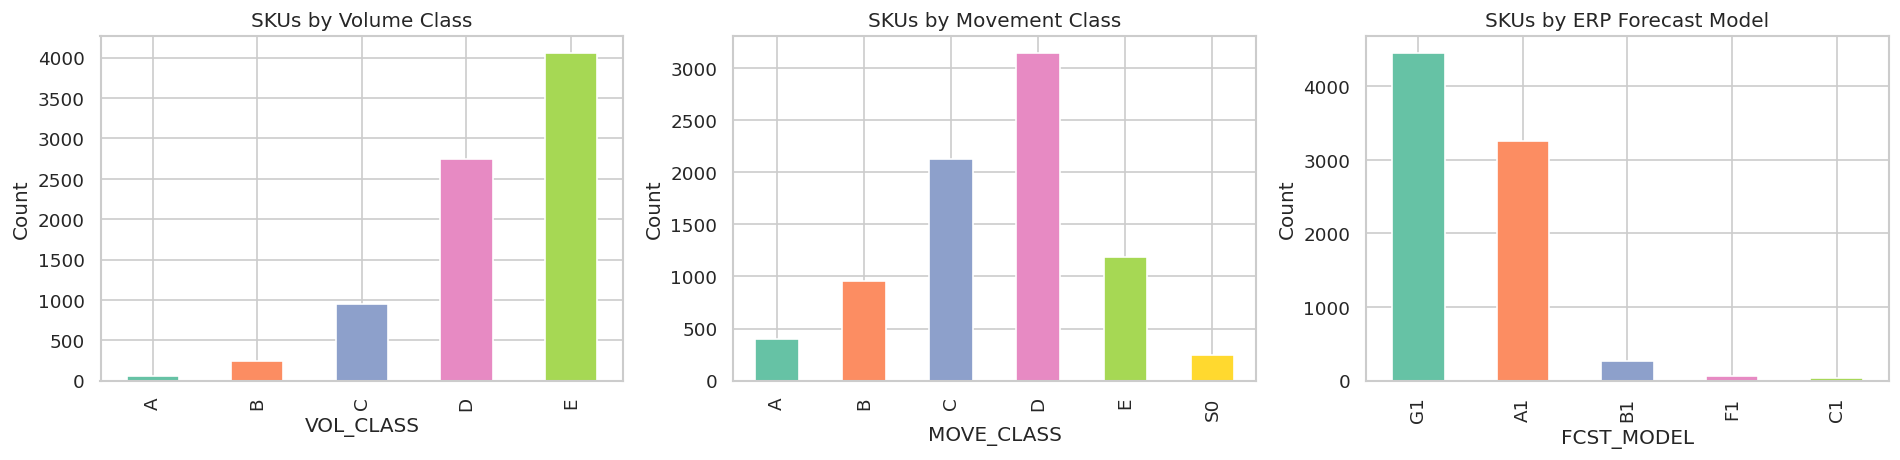

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

meta["VOL_CLASS"].value_counts().sort_index().plot.bar(ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_title("SKUs by Volume Class"); axes[0].set_ylabel("Count")

meta["MOVE_CLASS"].value_counts().sort_index().plot.bar(ax=axes[1], color=sns.color_palette("Set2"))
axes[1].set_title("SKUs by Movement Class"); axes[1].set_ylabel("Count")

meta["FCST_MODEL"].value_counts().plot.bar(ax=axes[2], color=sns.color_palette("Set2"))
axes[2].set_title("SKUs by ERP Forecast Model"); axes[2].set_ylabel("Count")

plt.tight_layout(); plt.show()


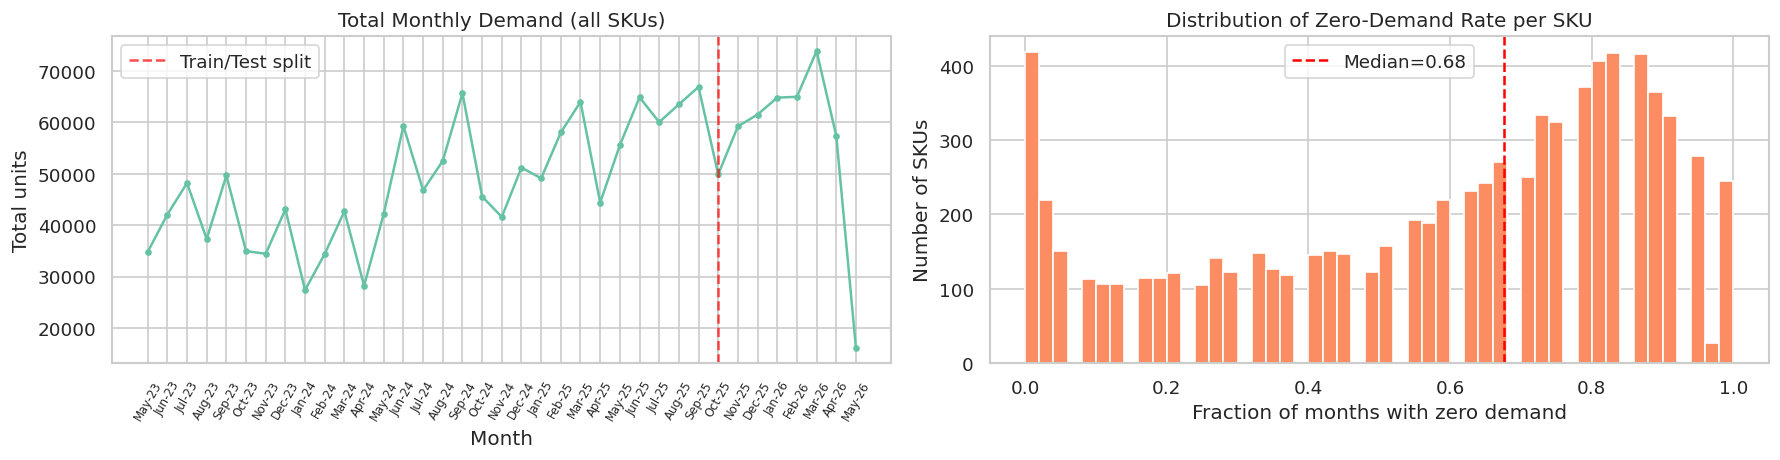

Median zero-rate: 67.57%
SKUs with >90% zeros: 883 (10.9%)
SKUs with ALL months zero: 245


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Aggregate demand
total_demand = demand.sum(axis=0)
axes[0].plot([m.strftime("%b-%y") for m in cal_months], total_demand, marker="o", markersize=3, linewidth=1.5)
axes[0].set_title("Total Monthly Demand (all SKUs)")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Total units")
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
axes[0].axvline(x=29, color="red", linestyle="--", alpha=0.7, label="Train/Test split")
axes[0].legend()

# Zero-rate distribution
zero_rates = (demand == 0).mean(axis=1)
axes[1].hist(zero_rates, bins=50, edgecolor="white", color=sns.color_palette("Set2")[1])
axes[1].set_title("Distribution of Zero-Demand Rate per SKU")
axes[1].set_xlabel("Fraction of months with zero demand"); axes[1].set_ylabel("Number of SKUs")
med_zr = float(np.median(zero_rates))
axes[1].axvline(x=med_zr, color="red", linestyle="--", label=f"Median={med_zr:.2f}")
axes[1].legend()

plt.tight_layout(); plt.show()

print(f"Median zero-rate: {med_zr:.2%}")
print(f"SKUs with >90% zeros: {(zero_rates > 0.9).sum():,} ({(zero_rates > 0.9).mean():.1%})")
print(f"SKUs with ALL months zero: {(zero_rates == 1.0).sum():,}")


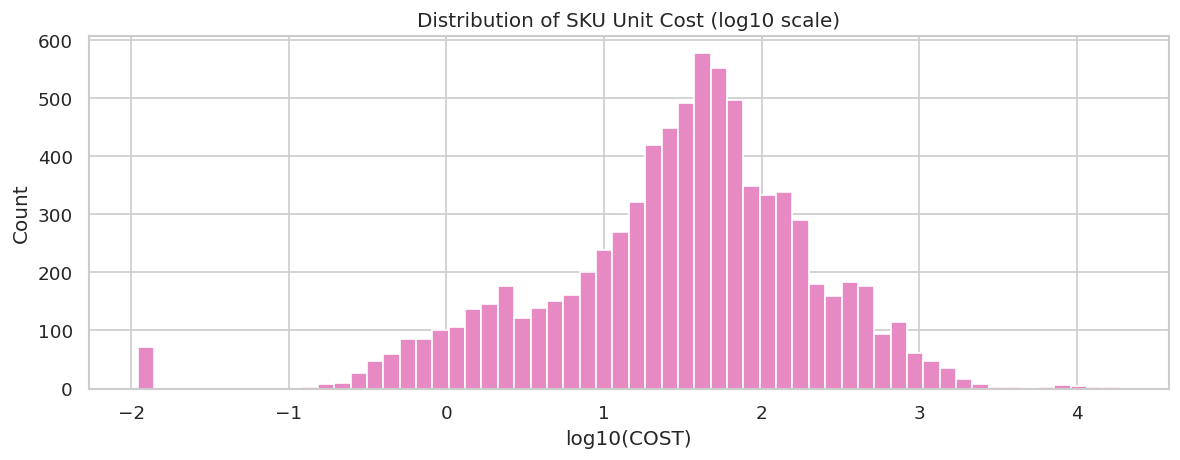

Cost range: 0.01 to 18710.41 | Median: 37.48


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(meta["COST"].clip(lower=0.01)), bins=60, edgecolor="white", color=sns.color_palette("Set2")[3])
ax.set_title("Distribution of SKU Unit Cost (log10 scale)")
ax.set_xlabel("log10(COST)"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()
print(f"Cost range: {meta['COST'].min():.2f} to {meta['COST'].max():.2f} | Median: {meta['COST'].median():.2f}")


## 4 — Demand Pattern Classification (Syntetos-Boylan)

| | Low CV² (< 0.49) | High CV² (≥ 0.49) |
|---|---|---|
| **Low ADI (< 1.32)** | Smooth | Erratic |
| **High ADI (≥ 1.32)** | Intermittent | Lumpy |

This determines which forecasting method suits each SKU best.


In [7]:
zero_rate = (demand == 0).mean(axis=1)
mean_dem = demand.mean(axis=1)
std_dem = demand.std(axis=1)
nz_mask = mean_dem > 0
cv = np.where(nz_mask, std_dem / np.where(nz_mask, mean_dem, 1.0), 0.0)
nonzero_counts = (demand > 0).sum(axis=1)   # how many of the 37 months had demand

def compute_adi(ts):
    nz = np.where(ts > 0)[0]
    return np.diff(nz).mean() if len(nz) >= 2 else len(ts)

adi = np.array([compute_adi(demand[i]) for i in range(len(demand))])
cv2 = cv ** 2

# Syntetos-Boylan classification for parts that actually move:
demand_type = np.where(
    adi >= 1.32,
    np.where(cv2 >= 0.49, "Lumpy", "Intermittent"),
    np.where(cv2 >= 0.49, "Erratic", "Smooth"),
)

# IMPORTANT: a part with ZERO demand across all 37 months is NOT "intermittent"
# in any useful sense - it is dead / obsolete. The raw SB formula mislabels these
# as "Intermittent" (an all-zero series gets ADI=37 -> rare, and CV2=0 -> consistent).
# We label them explicitly as "Dead/No-Demand" so they do not pollute the
# Intermittent bucket and so the per-pattern table is honest.
demand_type = np.where(nonzero_counts == 0, "Dead/No-Demand", demand_type)

meta["zero_rate"] = zero_rate
meta["mean_demand"] = mean_dem
meta["cv"] = cv
meta["adi"] = adi
meta["demand_type"] = demand_type

print("Demand pattern counts:")
print(pd.Series(demand_type).value_counts())
print(f"\n{(nonzero_counts == 0).sum():,} SKUs are Dead/No-Demand (zero demand in all 37 months)")
print(f"{(demand_type == 'Lumpy').mean():.1%} of SKUs are Lumpy (hardest ACTIVE pattern to forecast)")
print("\nNote: no ACTIVE SKU falls in the SB 'Intermittent' quadrant here - active")
print("intermittent parts have variable order sizes (CV2 >= 0.49), so they land in 'Lumpy'.")

Demand pattern counts:
Lumpy             5978
Erratic           1061
Smooth             780
Dead/No-Demand     245
Name: count, dtype: int64

245 SKUs are Dead/No-Demand (zero demand in all 37 months)
74.1% of SKUs are Lumpy (hardest ACTIVE pattern to forecast)

Note: no ACTIVE SKU falls in the SB 'Intermittent' quadrant here - active
intermittent parts have variable order sizes (CV2 >= 0.49), so they land in 'Lumpy'.


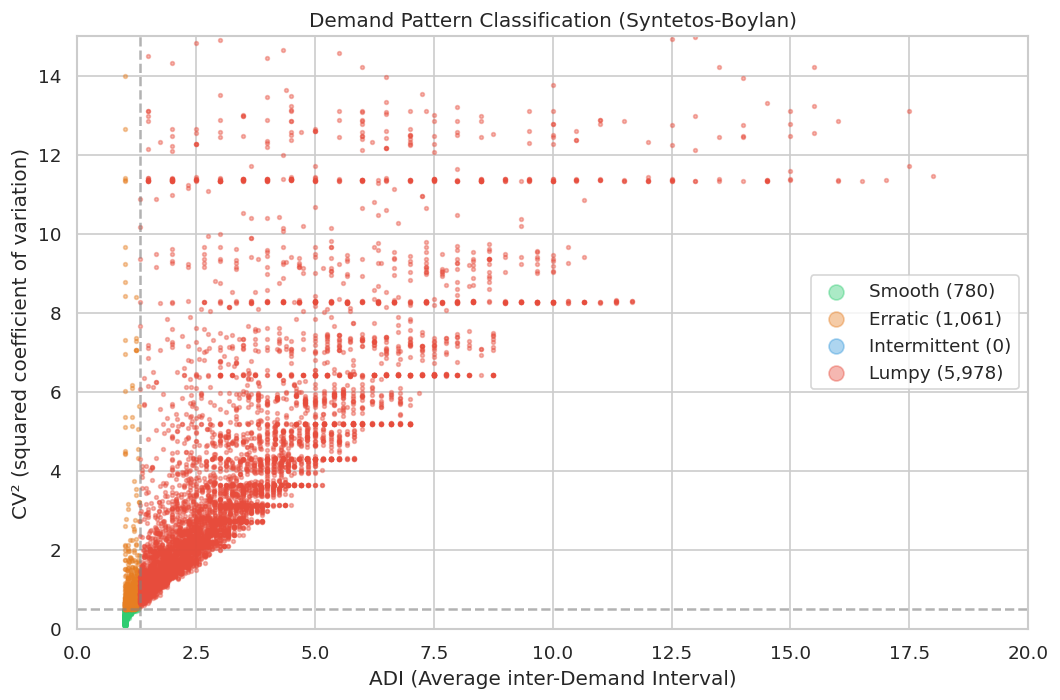

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"Smooth": "#2ecc71", "Erratic": "#e67e22", "Intermittent": "#3498db", "Lumpy": "#e74c3c"}
for dt, col in colors.items():
    mask = demand_type == dt
    ax.scatter(adi[mask], cv2[mask], s=5, alpha=0.4, label=f"{dt} ({mask.sum():,})", color=col)

ax.axvline(1.32, color="gray", linestyle="--", alpha=0.6)
ax.axhline(0.49, color="gray", linestyle="--", alpha=0.6)
ax.set_xlabel("ADI (Average inter-Demand Interval)")
ax.set_ylabel("CV² (squared coefficient of variation)")
ax.set_title("Demand Pattern Classification (Syntetos-Boylan)")
ax.set_xlim(0, min(adi.max(), 20)); ax.set_ylim(0, min(cv2.max(), 15))
ax.legend(markerscale=4)
plt.tight_layout(); plt.show()


In [9]:
ct = pd.crosstab(meta["MOVE_CLASS"], meta["demand_type"], margins=True)
print("Demand pattern vs Movement class cross-tab:")
display(ct)


Demand pattern vs Movement class cross-tab:


demand_type,Dead/No-Demand,Erratic,Lumpy,Smooth,All
MOVE_CLASS,,,,,
A,0,120,6,276,402
B,0,438,93,426,957
C,0,409,1637,78,2124
D,1,40,3108,0,3149
E,0,54,1134,0,1188
S0,244,0,0,0,244
All,245,1061,5978,780,8064


## 5 — Train / Test Split

- **Training**: May-2023 to Oct-2025 (months 0–29)
- **Test (backtest)**: Nov-2025 to Apr-2026 (months 30–35, 6 months)
- **Forward forecast**: Jun–Aug 2026 (3 months ahead)


In [10]:
EVAL_TRAIN_END = 29
PROD_TRAIN_END = 35
TEST_INDICES = list(range(30, 36))
N_TEST = len(TEST_INDICES)

print("Training period :", cal_months[0].strftime("%b-%Y"), "->", cal_months[EVAL_TRAIN_END].strftime("%b-%Y"))
print("Test periods    :", [cal_months[i].strftime("%b-%Y") for i in TEST_INDICES])
print("Total SKUs      :", len(demand))


Training period : May-2023 -> Oct-2025
Test periods    : ['Nov-2025', 'Dec-2025', 'Jan-2026', 'Feb-2026', 'Mar-2026', 'Apr-2026']
Total SKUs      : 8064


## 6 — Forecasting Models

**Statistical (intermittent-demand specialists):**
- **SES** — Simple Exponential Smoothing (α=0.20)
- **Croston** — tracks demand size and interval separately
- **SBA** — bias-corrected Croston (Syntetos-Boylan 2005)
- **TSB** — Teunter-Syntetos-Babai (handles obsolescence)

**Machine Learning (gradient boosting):**
- **LightGBM** — Tweedie loss (designed for non-negative data with zeros)
- **XGBoost** — same Tweedie objective
- **Random Forest** — baseline tree ensemble
- **Ensemble** — average of SBA + LightGBM

All features are computed **point-in-time** (history up to the prediction month only — no look-ahead leakage).


In [11]:
# Vectorised statistical models
def croston_batch(history, alpha=0.15, variant="sba"):
    n, L = history.shape
    z = np.zeros(n); p = np.ones(n); q = np.zeros(n, dtype=int); init = np.zeros(n, dtype=bool)
    for t in range(L):
        y = history[:, t]; q += 1; nz = y > 0
        first = nz & ~init
        z[first] = y[first]; p[first] = q[first]; init[first] = True; q[first] = 0
        upd = nz & init & ~first
        z[upd] = (1 - alpha) * z[upd] + alpha * y[upd]
        p[upd] = (1 - alpha) * p[upd] + alpha * q[upd]; q[upd] = 0
    rate = np.where(init & (p > 0), z / np.where(p > 0, p, 1.0), 0.0)
    if variant == "sba": rate *= (1 - alpha / 2.0)
    return np.maximum(rate, 0.0)

def tsb_batch(history, alpha_d=0.15, alpha_z=0.15):
    n, L = history.shape
    z = np.zeros(n); q = np.zeros(n); init = np.zeros(n, dtype=bool)
    for t in range(L):
        y = history[:, t]; nz = y > 0
        first = nz & ~init
        z[first] = y[first]; q[first] = 1.0 / (t + 1); init[first] = True
        active = init & ~first
        q[active & nz] = (1 - alpha_d) * q[active & nz] + alpha_d
        z[active & nz] = (1 - alpha_z) * z[active & nz] + alpha_z * y[active & nz]
        q[active & ~nz] = (1 - alpha_d) * q[active & ~nz]
    return np.maximum(np.where(init, q * z, 0.0), 0.0)

def ses_batch(history, alpha=0.20):
    n, L = history.shape
    if L == 0: return np.zeros(n)
    S = history[:, 0].astype(float).copy()
    for t in range(1, L): S = (1 - alpha) * S + alpha * history[:, t]
    return np.maximum(S, 0.0)

print("Statistical model functions defined.")


Statistical model functions defined.


In [12]:
# ML Feature Engineering (point-in-time, no leakage)
FEATURE_NAMES = [
    "lag1", "lag2", "lag3", "lag6", "lag12",
    "roll3_mean", "roll6_mean", "roll12_mean", "roll3_std", "roll6_max",
    "trend_ratio", "months_since_last", "nonzero_cnt12", "adi_pit",
    "zero_rate_pit", "cv_pit", "season_lag12_ratio",
    "month_sin", "month_cos",
    "vol_class", "move_class", "brand", "log_cost",
]

def encode_static(meta_df):
    vol = LabelEncoder().fit_transform(meta_df["VOL_CLASS"].astype(str))
    move = LabelEncoder().fit_transform(meta_df["MOVE_CLASS"].astype(str))
    brand = LabelEncoder().fit_transform(meta_df["BRAND"].astype(str))
    log_cost = np.log1p(np.maximum(meta_df["COST"].values, 0))
    return np.column_stack([vol, move, brand, log_cost]).astype(float)

def build_features(history, month_ts, static_feats):
    n, L = history.shape
    def lag(k): return history[:, -k] if L >= k else np.zeros(n)
    l1, l2, l3, l6, l12 = lag(1), lag(2), lag(3), lag(6), lag(12)
    r3 = history[:, -min(3, L):].mean(axis=1)
    r6 = history[:, -min(6, L):].mean(axis=1)
    r12 = history[:, -min(12, L):].mean(axis=1)
    rs3 = history[:, -min(3, L):].std(axis=1)
    rmax6 = history[:, -min(6, L):].max(axis=1)
    prev3 = history[:, -min(6, L):-min(3, L)] if L >= 6 else history[:, :max(L-3, 0)]
    prev3_mean = prev3.mean(axis=1) if prev3.shape[1] > 0 else r3
    trend_ratio = np.clip(r3 / np.where(prev3_mean > 0, prev3_mean, 1.0), 0, 5)
    months_since = np.full(n, L, dtype=float)
    for i in range(n):
        nzz = np.where(history[i] > 0)[0]
        if len(nzz): months_since[i] = L - 1 - nzz[-1]
    nonzero_cnt12 = (history[:, -min(12, L):] > 0).sum(axis=1).astype(float)
    adi_pit = np.array([np.diff(np.where(history[i] > 0)[0]).mean()
                        if (history[i] > 0).sum() >= 2 else float(L) for i in range(n)])
    zero_rate_pit = (history == 0).mean(axis=1)
    mean_pit = history.mean(axis=1)
    std_pit = history.std(axis=1)
    cv_pit = np.where(mean_pit > 0, std_pit / np.where(mean_pit > 0, mean_pit, 1.0), 0.0)
    season_ratio = np.clip(l12 / np.where(r12 > 0, r12, 1.0), 0, 5)
    m = month_ts.month
    month_sin = np.full(n, np.sin(2 * np.pi * m / 12))
    month_cos = np.full(n, np.cos(2 * np.pi * m / 12))
    return np.column_stack([l1, l2, l3, l6, l12, r3, r6, r12, rs3, rmax6,
                            trend_ratio, months_since, nonzero_cnt12, adi_pit,
                            zero_rate_pit, cv_pit, season_ratio,
                            month_sin, month_cos, static_feats])

static_feats = encode_static(meta)
print(f"Features per SKU: {len(FEATURE_NAMES)}")
print("Feature list:", FEATURE_NAMES)


Features per SKU: 23
Feature list: ['lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'roll3_mean', 'roll6_mean', 'roll12_mean', 'roll3_std', 'roll6_max', 'trend_ratio', 'months_since_last', 'nonzero_cnt12', 'adi_pit', 'zero_rate_pit', 'cv_pit', 'season_lag12_ratio', 'month_sin', 'month_cos', 'vol_class', 'move_class', 'brand', 'log_cost']


In [13]:
# Build training data
print("Building training matrix (point-in-time features, months 12-29)...")
X_rows, y_rows = [], []
for t in range(12, EVAL_TRAIN_END + 1):
    X_rows.append(build_features(demand[:, :t], cal_months[t], static_feats))
    y_rows.append(demand[:, t])
X_train = np.vstack(X_rows)
y_train = np.concatenate(y_rows)
print(f"Training samples: {X_train.shape[0]:,} ({X_train.shape[0] // len(demand)} months x {len(demand):,} SKUs)")
print(f"Features: {X_train.shape[1]}")
print(f"Target range: {y_train.min():.1f} - {y_train.max():.1f}")


Building training matrix (point-in-time features, months 12-29)...


Training samples: 145,152 (18 months x 8,064 SKUs)
Features: 23
Target range: 0.0 - 14755.3


In [14]:
# Train ML models
LGBM_PARAMS = dict(objective="tweedie", tweedie_variance_power=1.5,
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

XGB_PARAMS = dict(objective="reg:tweedie", tweedie_variance_power=1.5,
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

RF_PARAMS = dict(n_estimators=100, max_depth=8, min_samples_leaf=5,
    n_jobs=-1, random_state=RANDOM_STATE)

print("Training LightGBM..."); lgbm_model = lgb.LGBMRegressor(**LGBM_PARAMS).fit(X_train, y_train); print("  done")
print("Training XGBoost..."); xgb_model = xgb.XGBRegressor(**XGB_PARAMS).fit(X_train, y_train); print("  done")
print("Training Random Forest..."); rf_model = RandomForestRegressor(**RF_PARAMS).fit(X_train, y_train); print("  done")


Training LightGBM...


  done
Training XGBoost...


  done
Training Random Forest...


  done


In [15]:
# Zero-demand classifier (gate)
print("Training zero-demand classifier...")
y_zero = (y_train == 0).astype(int)
zero_clf = lgb.LGBMClassifier(
    n_estimators=300, num_leaves=31, min_child_samples=30,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
).fit(X_train, y_zero)
print(f"  done. Zero months in training: {y_zero.mean():.1%}")

def apply_zero_gate(preds, history, t_idx, static_feats, threshold=ZERO_THRESHOLD):
    X = build_features(history, cal_months[t_idx], static_feats)
    zmask = zero_clf.predict(X).astype(bool)
    out = np.maximum(preds, 0.0)
    out = np.where(zmask, 0.0, out)
    out = np.where(out < threshold, 0.0, out)
    return out


Training zero-demand classifier...


  done. Zero months in training: 55.9%


## 7 — Evaluation Metrics

- **WAPE** — primary KPI for intermittent demand (volume-weighted)
- **vWAPE** — value-weighted by COST (money at risk)
- **MASE** — per-series scaling; < 1 beats naive (repeating last month)
- **Bias%** — positive = over-forecast, negative = under-forecast (stockout risk)
- **MAPE_nz** — MAPE on non-zero actual months only


In [16]:
def naive_scale_per_series(history):
    if history.shape[1] < 2: scale = history.mean(axis=1)
    else: scale = np.abs(np.diff(history, axis=1)).mean(axis=1)
    fallback = history.mean(axis=1)
    scale = np.where(scale > 1e-8, scale, fallback)
    return np.where(scale > 1e-8, scale, 1.0)

def compute_metrics(actual, forecast, naive_scale, cost=None):
    forecast = np.maximum(forecast, 0.0)
    abs_err = np.abs(actual - forecast)
    wape = abs_err.sum() / actual.sum() * 100 if actual.sum() > 0 else np.nan
    if cost is not None:
        w = cost.reshape(-1, 1)
        denom = (w * np.abs(actual)).sum()
        vwape = (w * abs_err).sum() / denom * 100 if denom > 0 else np.nan
    else: vwape = np.nan
    mae_series = abs_err.mean(axis=1)
    mase_series = mae_series / naive_scale
    mase_med = float(np.median(mase_series))
    bias = (forecast - actual).sum() / actual.sum() * 100 if actual.sum() > 0 else np.nan
    nz = actual > 0
    mape_nz = float(np.abs((actual[nz] - forecast[nz]) / actual[nz]).mean() * 100) if nz.any() else np.nan
    return {"WAPE": round(wape, 2), "vWAPE": round(vwape, 2),
            "MASE_med": round(mase_med, 3), "Bias%": round(bias, 2),
            "MAPE_nz": round(mape_nz, 1), "MAE": round(float(mae_series.mean()), 4),
            "RMSE": round(float(np.sqrt(((actual - forecast) ** 2).mean())), 4)}

print("Metrics functions defined.")


Metrics functions defined.


## 8 — Run All Models on Test Period (Nov-25 → Apr-26)

In [17]:
actual_test = demand[:, TEST_INDICES]
naive_scales = naive_scale_per_series(demand[:, :TEST_INDICES[0]])
cost = meta["COST"].values.astype(float)

all_preds = {}
model_names = ["SBA", "Croston", "TSB", "SES", "LightGBM", "XGBoost", "RandomForest", "Naive(lag1)"]
for name in model_names:
    all_preds[name] = np.zeros_like(actual_test, dtype=float)

print("Running all models on 6 test months...")
for j, t_idx in enumerate(TEST_INDICES):
    hist = demand[:, :t_idx]
    all_preds["SBA"][:, j] = croston_batch(hist, 0.15, "sba")
    all_preds["Croston"][:, j] = croston_batch(hist, 0.15, "croston")
    all_preds["TSB"][:, j] = tsb_batch(hist, 0.15, 0.15)
    all_preds["SES"][:, j] = ses_batch(hist, 0.20)
    all_preds["Naive(lag1)"][:, j] = demand[:, t_idx - 1]
    X_t = build_features(hist, cal_months[t_idx], static_feats)
    all_preds["LightGBM"][:, j] = lgbm_model.predict(X_t)
    all_preds["XGBoost"][:, j] = xgb_model.predict(X_t)
    all_preds["RandomForest"][:, j] = rf_model.predict(X_t)

# Ensemble: SBA + LightGBM average
all_preds["Ensemble"] = 0.5 * (all_preds["SBA"] + all_preds["LightGBM"])

# Apply zero gate
print("Applying zero-demand gate...")
for name in list(all_preds.keys()):
    gated = all_preds[name].copy()
    for j, t_idx in enumerate(TEST_INDICES):
        gated[:, j] = apply_zero_gate(all_preds[name][:, j], demand[:, :t_idx], t_idx, static_feats)
    all_preds[name] = gated
print("All models done.")


Running all models on 6 test months...


Applying zero-demand gate...


All models done.


## 9 — Model Comparison: Leaderboard & Charts

This is the main comparison of all 9 approaches on the 6-month backtest window.


In [18]:
results = []
for name, preds in all_preds.items():
    m = compute_metrics(actual_test, preds, naive_scales, cost)
    m["model"] = name
    results.append(m)

leaderboard = pd.DataFrame(results).set_index("model").sort_values("WAPE")
print("MODEL LEADERBOARD (sorted by WAPE — lower is better):")
print("=" * 80)
display(leaderboard)
print("\nMASE < 1.0 means the model beats simply repeating last month's demand.")


MODEL LEADERBOARD (sorted by WAPE — lower is better):


,WAPE,vWAPE,MASE_med,Bias%,MAPE_nz,MAE,RMSE
model,,,,,,,
SES,38.62,56.20,0.826,-10.43,69.7,3.0462,36.2949
TSB,39.04,57.22,0.825,-12.90,69.5,3.0796,36.7413
Ensemble,39.13,55.57,0.818,-16.48,67.7,3.0860,42.2629
RandomForest,39.38,58.95,0.823,-7.44,68.9,3.1060,35.7979
Croston,39.56,59.42,0.832,-13.85,71.0,3.1202,36.7837
SBA,40.41,58.90,0.830,-20.32,69.8,3.1875,40.7754
LightGBM,40.99,57.29,0.819,-12.68,67.6,3.2329,47.3738
XGBoost,43.38,54.57,0.818,-17.55,67.5,3.4218,68.9017
Naive(lag1),45.11,63.25,0.924,-6.56,83.7,3.5579,41.2866



MASE < 1.0 means the model beats simply repeating last month's demand.


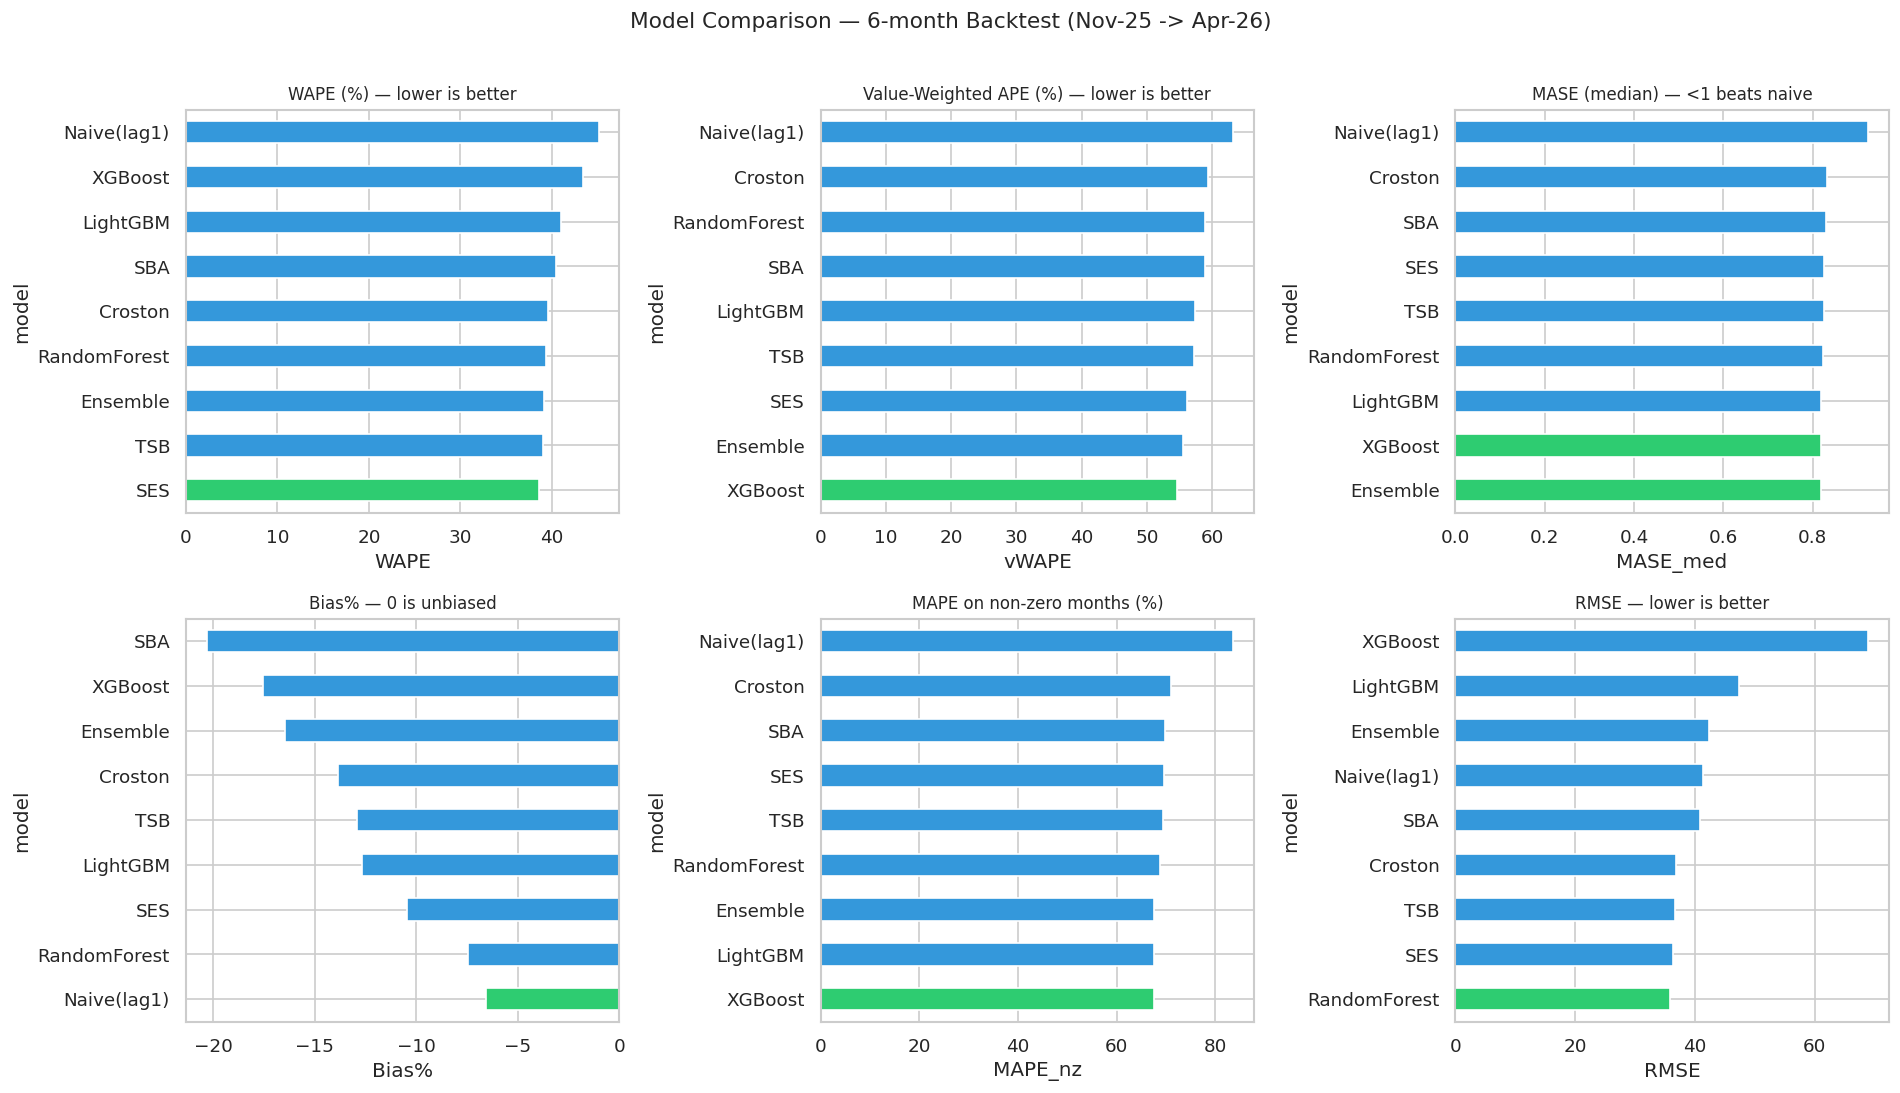

In [19]:
# Visual comparison — bar charts
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

metrics_plot = [("WAPE", "WAPE (%) — lower is better", True),
                ("vWAPE", "Value-Weighted APE (%) — lower is better", True),
                ("MASE_med", "MASE (median) — <1 beats naive", True),
                ("Bias%", "Bias% — 0 is unbiased", False),
                ("MAPE_nz", "MAPE on non-zero months (%)", True),
                ("RMSE", "RMSE — lower is better", True)]

for ax, (metric, title, lower_better) in zip(axes.flat, metrics_plot):
    vals = leaderboard[metric].sort_values(ascending=lower_better)
    bar_colors = ["#2ecc71" if v == vals.iloc[0] else "#3498db" for v in vals]
    vals.plot.barh(ax=ax, color=bar_colors)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(metric)

plt.suptitle("Model Comparison — 6-month Backtest (Nov-25 -> Apr-26)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


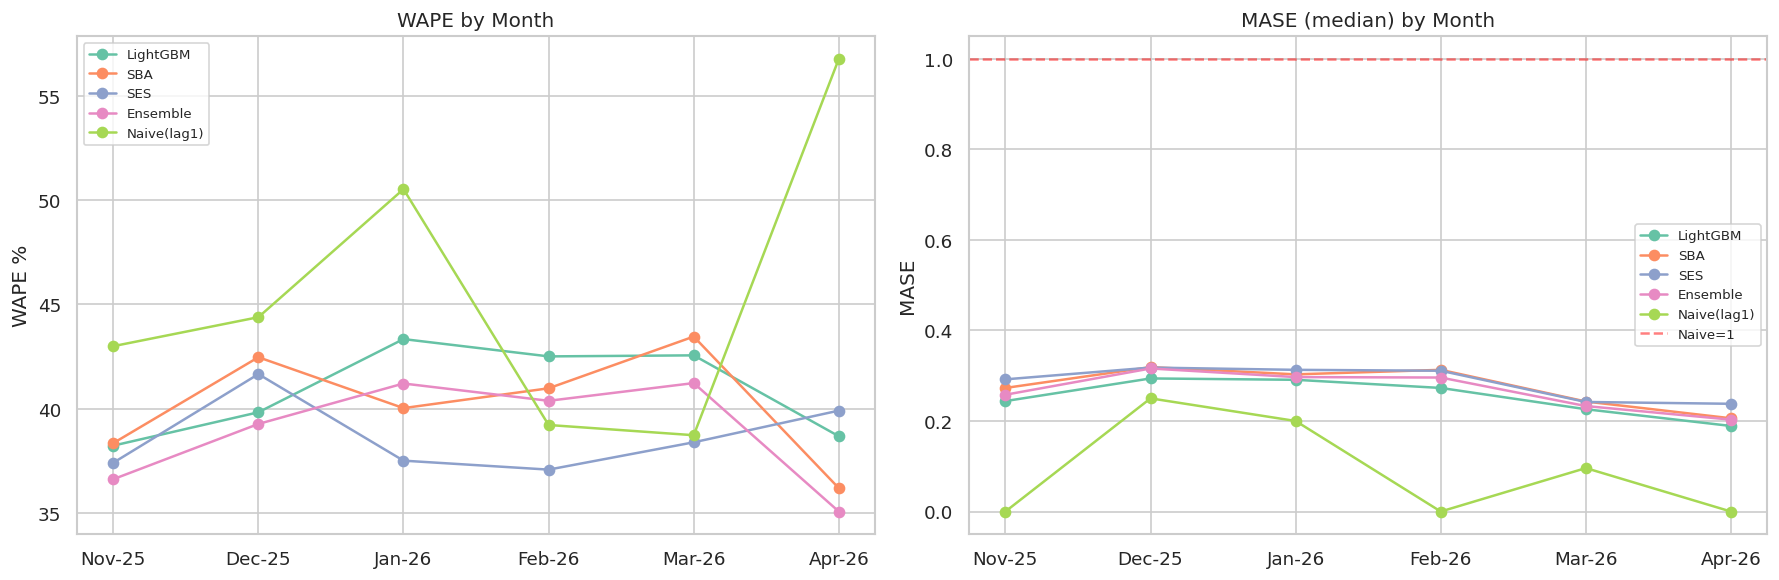

In [20]:
# Monthly performance evolution (selected models)
monthly_results = []
for name, preds in all_preds.items():
    for j, t_idx in enumerate(TEST_INDICES):
        act_j = actual_test[:, j:j+1]; pred_j = preds[:, j:j+1]
        m = compute_metrics(act_j, pred_j, naive_scales, cost)
        m["model"] = name; m["month"] = cal_months[t_idx].strftime("%b-%y")
        monthly_results.append(m)
monthly_df = pd.DataFrame(monthly_results)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
show_models = ["LightGBM", "SBA", "SES", "Ensemble", "Naive(lag1)"]
for name in show_models:
    sub = monthly_df[monthly_df["model"] == name]
    axes[0].plot(sub["month"], sub["WAPE"], marker="o", label=name)
    axes[1].plot(sub["month"], sub["MASE_med"], marker="o", label=name)

axes[0].set_title("WAPE by Month"); axes[0].set_ylabel("WAPE %"); axes[0].legend(fontsize=8)
axes[1].set_title("MASE (median) by Month"); axes[1].set_ylabel("MASE")
axes[1].axhline(1.0, color="red", linestyle="--", alpha=0.5, label="Naive=1"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 10 — Performance by Demand Pattern

Different methods excel on different demand types. This drives the hybrid routing strategy.


In [21]:
pattern_results = []
for patt in sorted(meta["demand_type"].unique()):
    mask = (meta["demand_type"] == patt).values
    for name, preds in all_preds.items():
        m = compute_metrics(actual_test[mask], preds[mask], naive_scales[mask], cost[mask])
        m["demand_type"] = patt; m["model"] = name; m["n_sku"] = int(mask.sum())
        pattern_results.append(m)

patt_df = pd.DataFrame(pattern_results)

# Coverage table - shows EVERY category so nothing is silently hidden.
# (WAPE = sum|err| / sum(actual) is undefined when a group has 0 demand in the
#  test window, which is why such a row would otherwise vanish from the pivot.)
coverage = []
for patt in sorted(meta["demand_type"].unique()):
    mask = (meta["demand_type"] == patt).values
    tot = float(actual_test[mask].sum())
    coverage.append({"demand_type": patt, "n_SKU": int(mask.sum()),
                     "test_window_demand": round(tot, 1),
                     "WAPE_defined": "Yes" if tot > 0 else "No (0 demand)"})
print("Category coverage (explains why a row may have no WAPE):")
display(pd.DataFrame(coverage))

# dropna=False keeps all rows visible even when WAPE is undefined (NaN).
pivot_wape = patt_df.pivot_table(index="demand_type", columns="model",
                                 values="WAPE", dropna=False)
print("\nWAPE by Demand Pattern x Model (NaN = no actual demand in test window):")
display(pivot_wape.round(1))

Category coverage (explains why a row may have no WAPE):


,demand_type,n_SKU,test_window_demand,WAPE_defined
0,Dead/No-Demand,245,0.0,No (0 demand)
1,Erratic,1061,86714.9,Yes
2,Lumpy,5978,44774.2,Yes
3,Smooth,780,250139.2,Yes



WAPE by Demand Pattern x Model (NaN = no actual demand in test window):


model,Croston,Ensemble,LightGBM,Naive(lag1),RandomForest,SBA,SES,TSB,XGBoost
demand_type,,,,,,,,,
Dead/No-Demand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Erratic,54.9,51.4,51.5,57.8,52.6,55.0,51.8,53.0,50.4
Lumpy,89.1,87.5,86.9,98.0,87.2,89.2,87.9,88.3,87.1
Smooth,25.4,26.2,29.1,31.2,26.2,26.6,25.2,25.4,33.1


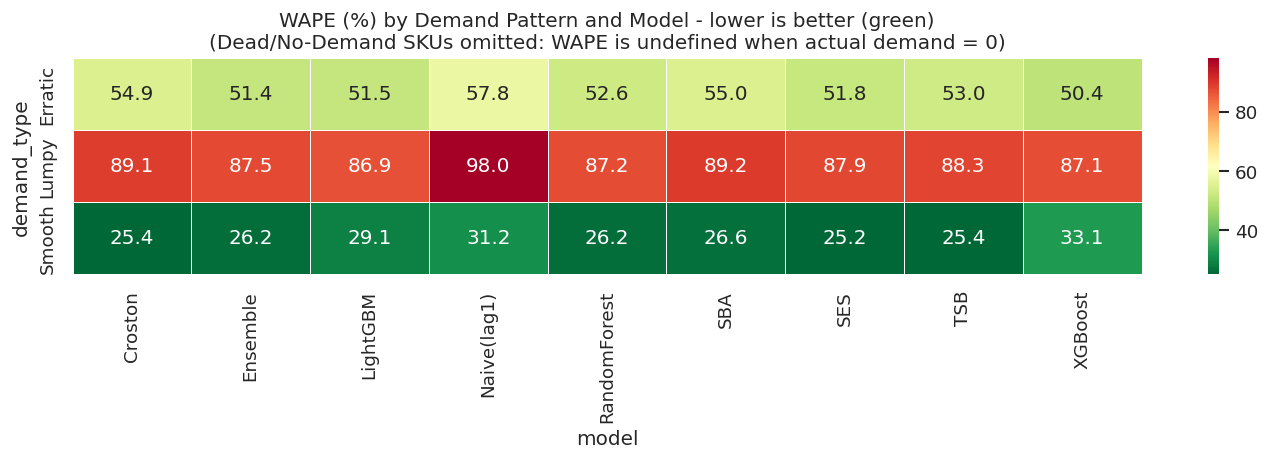

In [22]:
# Plot only the patterns that have a defined WAPE (drop the all-NaN Dead row)
plot_df = pivot_wape.dropna(how="all")
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(plot_df.round(1), annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax, linewidths=0.5)
ax.set_title("WAPE (%) by Demand Pattern and Model - lower is better (green)\n"
             "(Dead/No-Demand SKUs omitted: WAPE is undefined when actual demand = 0)")
plt.tight_layout(); plt.show()

In [23]:
# Best model per demand pattern (hybrid routing)
routing = {}
for patt in sorted(meta["demand_type"].unique()):
    if patt == "Dead/No-Demand":
        routing[patt] = "Zero (no demand)"   # forecast 0 for dead parts
        continue
    sub = patt_df[patt_df["demand_type"] == patt].dropna(subset=["WAPE"])
    if len(sub) > 0:
        routing[patt] = sub.loc[sub["WAPE"].idxmin(), "model"]
    else:
        sub2 = patt_df[patt_df["demand_type"] == patt].dropna(subset=["MASE_med"])
        routing[patt] = sub2.loc[sub2["MASE_med"].idxmin(), "model"] if len(sub2) > 0 else "SBA"

print("\nOptimal model routing (demand pattern -> best model):")
for k, v in routing.items():
    print(f"  {k:18s} -> {v}")


Optimal model routing (demand pattern -> best model):
  Dead/No-Demand     -> Zero (no demand)
  Erratic            -> XGBoost
  Lumpy              -> LightGBM
  Smooth             -> SES


## 11 — Feature Importance (LightGBM)

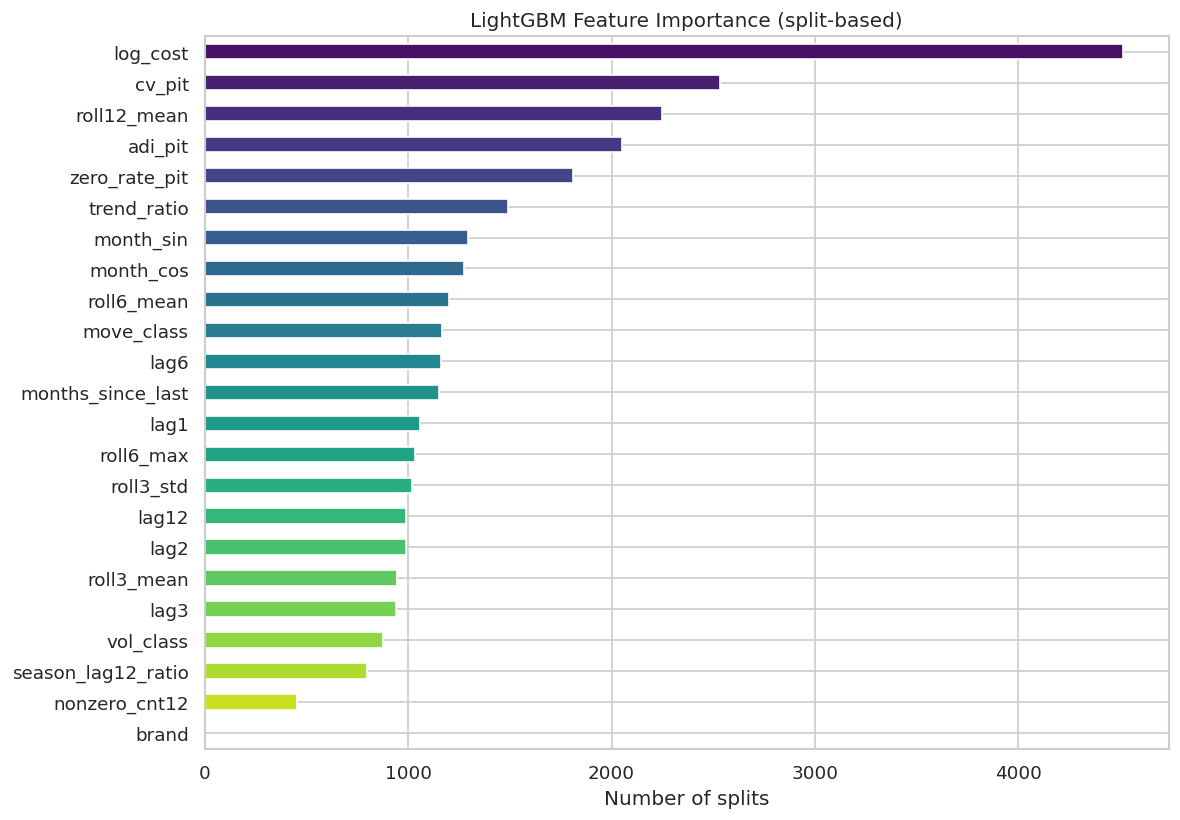


Top 10 features:
log_cost         4514
cv_pit           2532
roll12_mean      2250
adi_pit          2052
zero_rate_pit    1813
trend_ratio      1490
month_sin        1293
month_cos        1276
roll6_mean       1201
move_class       1165


In [24]:
fi = pd.Series(lgbm_model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
fi.plot.barh(ax=ax, color=sns.color_palette("viridis", len(fi)))
ax.set_title("LightGBM Feature Importance (split-based)")
ax.set_xlabel("Number of splits"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("\nTop 10 features:")
print(fi.head(10).to_string())


## 12 — Error Analysis

Examining the hybrid (pattern-routed) model's errors in detail:
- Error distributions
- Bias by movement class
- Worst-predicted SKUs
- Sample time series


In [25]:
# Build hybrid predictions
hybrid_preds = np.zeros_like(actual_test)
for patt, model_name in routing.items():
    mask = (meta["demand_type"] == patt).values
    if model_name in all_preds:
        hybrid_preds[mask] = all_preds[model_name][mask]
    # Dead/No-Demand parts keep their forecast at 0 (correct by construction)

errors = hybrid_preds - actual_test
abs_errors = np.abs(errors)
pct_errors = np.where(actual_test > 0, errors / actual_test * 100, np.nan)

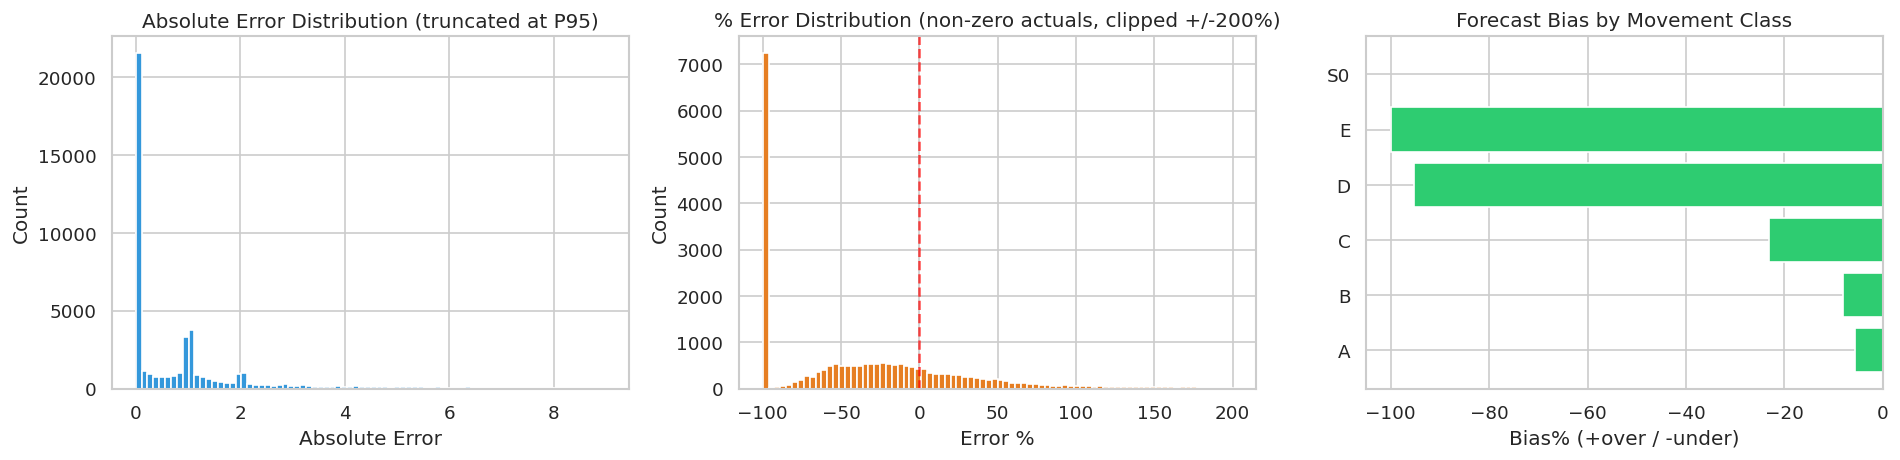

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# a) Absolute error distribution
flat_ae = abs_errors.flatten()
axes[0].hist(flat_ae[flat_ae < np.percentile(flat_ae, 95)], bins=80, edgecolor="white", color="#3498db")
axes[0].set_title("Absolute Error Distribution (truncated at P95)")
axes[0].set_xlabel("Absolute Error"); axes[0].set_ylabel("Count")

# b) Percentage error distribution
flat_pct = pct_errors[~np.isnan(pct_errors)]
clip_pct = flat_pct[(flat_pct > -200) & (flat_pct < 200)]
axes[1].hist(clip_pct, bins=80, edgecolor="white", color="#e67e22")
axes[1].axvline(0, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("% Error Distribution (non-zero actuals, clipped +/-200%)")
axes[1].set_xlabel("Error %"); axes[1].set_ylabel("Count")

# c) Bias by MOVE_CLASS
bias_by_class = []
for cls in sorted(meta["MOVE_CLASS"].unique()):
    mask = (meta["MOVE_CLASS"] == cls).values
    act_c = actual_test[mask]; pred_c = hybrid_preds[mask]
    b = (pred_c - act_c).sum() / act_c.sum() * 100 if act_c.sum() > 0 else 0
    bias_by_class.append({"MOVE_CLASS": cls, "Bias%": round(b, 1)})
bias_cls_df = pd.DataFrame(bias_by_class)
axes[2].barh(bias_cls_df["MOVE_CLASS"], bias_cls_df["Bias%"],
             color=["#e74c3c" if b > 0 else "#2ecc71" for b in bias_cls_df["Bias%"]])
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Forecast Bias by Movement Class"); axes[2].set_xlabel("Bias% (+over / -under)")

plt.tight_layout(); plt.show()


In [27]:
# Worst-predicted SKUs
sku_total_ae = abs_errors.sum(axis=1)
worst_idx = np.argsort(sku_total_ae)[-10:][::-1]

worst_df = meta.iloc[worst_idx][["PRODUCT", "MOVE_CLASS", "demand_type"]].copy()
worst_df["total_abs_error"] = sku_total_ae[worst_idx].round(1)
worst_df["mean_monthly_demand"] = actual_test[worst_idx].mean(axis=1).round(1)
worst_df["mean_forecast"] = hybrid_preds[worst_idx].mean(axis=1).round(1)
print("Top 10 worst-predicted SKUs (by total absolute error over 6 test months):")
display(worst_df.reset_index(drop=True))


Top 10 worst-predicted SKUs (by total absolute error over 6 test months):


,PRODUCT,MOVE_CLASS,demand_type,total_abs_error,mean_monthly_demand,mean_forecast
0,28LR112137,A,Smooth,15830.1,12440.6,11869.8
1,28RYH500420,A,Erratic,3374.0,632.7,206.5
2,28LR074133,B,Lumpy,1668.3,277.5,1.2
3,28FN106046,A,Smooth,1512.0,572.3,472.5
4,28LR050538,A,Smooth,1348.7,507.6,507.7
5,28LR029806,A,Erratic,1321.2,434.8,422.3
6,28LR152100,A,Erratic,1173.1,612.8,417.3
7,28LR181438,A,Smooth,1132.4,733.9,637.6
8,28LR073669,A,Smooth,1077.0,1274.9,1178.3
9,28LR154091,A,Smooth,1063.3,968.8,897.2


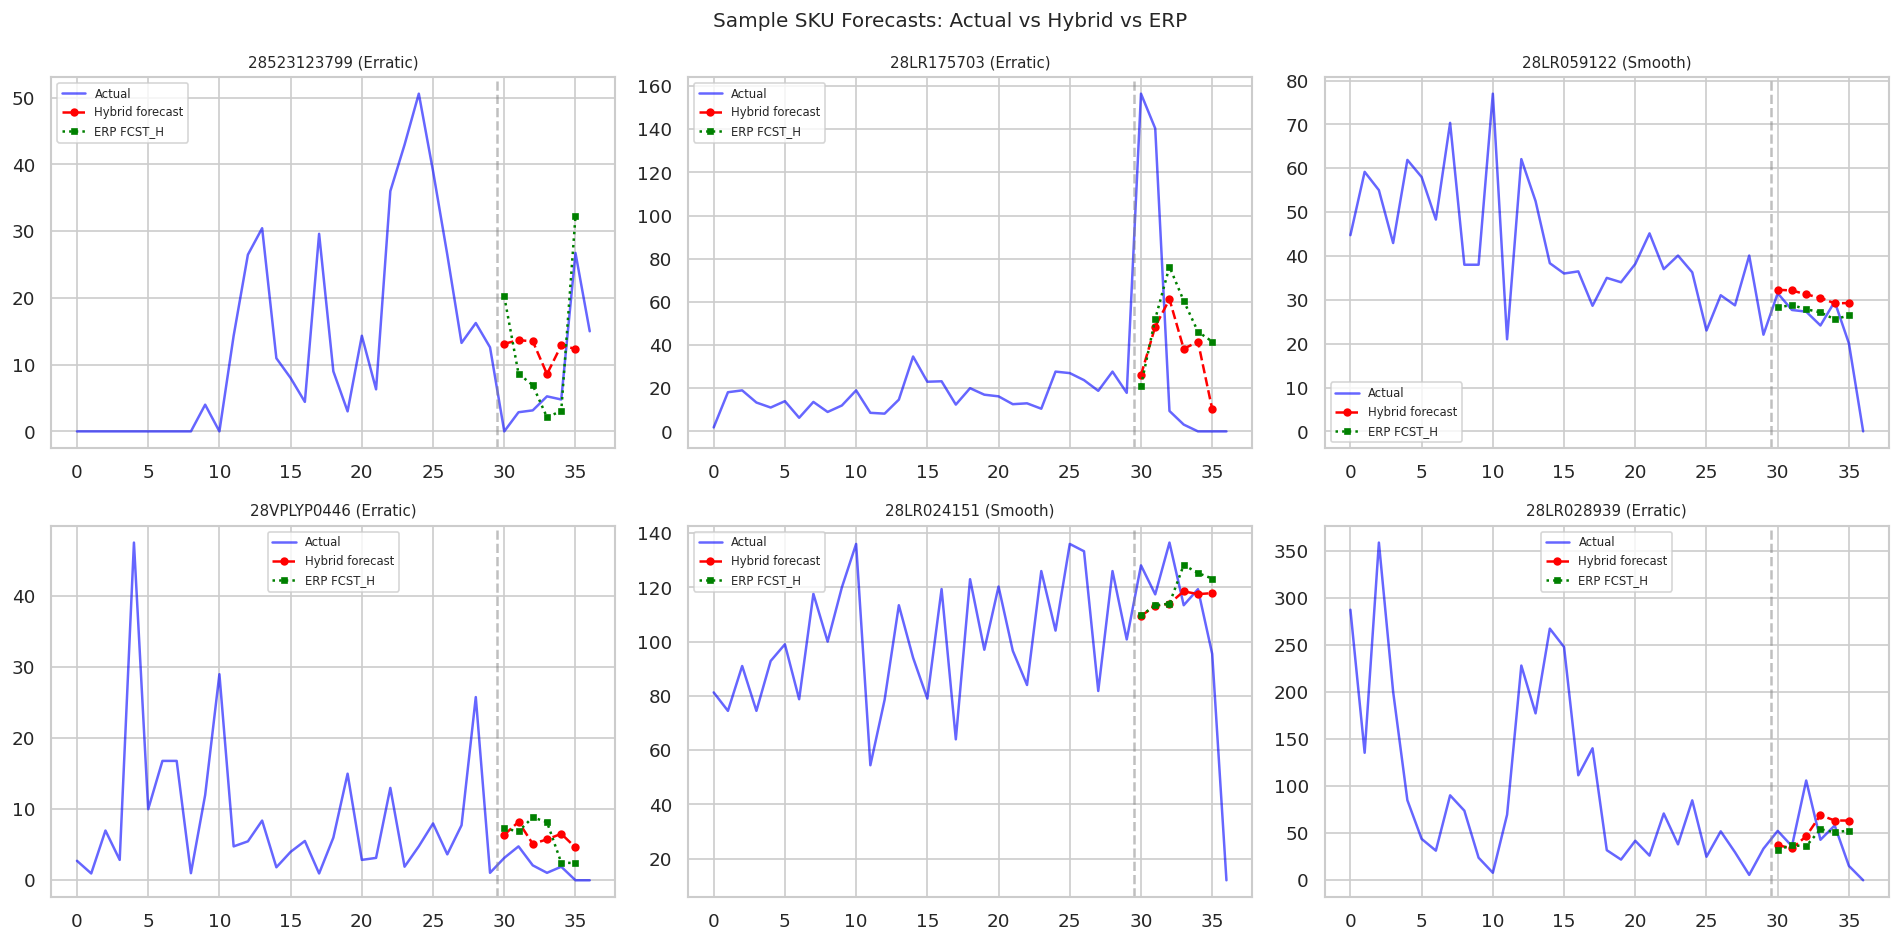

In [28]:
# Sample SKU time series: actual vs hybrid vs ERP
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
sample_indices = np.random.choice(np.where(mean_dem > 5)[0], size=6, replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    full_ts = demand[idx]
    ax.plot(range(N_MONTHS), full_ts, "b-", alpha=0.6, label="Actual")
    ax.plot(range(30, 36), hybrid_preds[idx], "r--o", markersize=4, label="Hybrid forecast")
    if fcst_h is not None:
        ax.plot(range(30, 36), np.maximum(fcst_h[idx, 30:36], 0), "g:s", markersize=3, label="ERP FCST_H")
    ax.axvline(29.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(f"{meta['PRODUCT'].iloc[idx]} ({meta['demand_type'].iloc[idx]})", fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Sample SKU Forecasts: Actual vs Hybrid vs ERP", fontsize=12)
plt.tight_layout(); plt.show()


## 13 — Hybrid Strategy vs ERP System Forecast (FCST_H)

The key question: does our pattern-routed hybrid beat the existing ERP system?


In [29]:
hybrid_metrics = compute_metrics(actual_test, hybrid_preds, naive_scales, cost)
sys_metrics = compute_metrics(actual_test, fcst_h[:, TEST_INDICES], naive_scales, cost) if fcst_h is not None else None

comp_df = pd.DataFrame({"Hybrid (ours)": hybrid_metrics, "ERP System (FCST_H)": sys_metrics}).T
print("OVERALL COMPARISON:")
display(comp_df)
print()
improvement = (sys_metrics["WAPE"] - hybrid_metrics["WAPE"]) / sys_metrics["WAPE"] * 100
print(f">>> WAPE improvement over ERP: {improvement:.1f}%")
print(f">>> MASE improvement: {(sys_metrics['MASE_med'] - hybrid_metrics['MASE_med']) / sys_metrics['MASE_med'] * 100:.1f}%")


OVERALL COMPARISON:


,WAPE,vWAPE,MASE_med,Bias%,MAPE_nz,MAE,RMSE
Hybrid (ours),38.17,54.58,0.818,-10.84,67.6,3.0107,36.4948
ERP System (FCST_H),40.95,58.23,0.976,-5.19,63.7,3.2299,40.3014



>>> WAPE improvement over ERP: 6.8%
>>> MASE improvement: 16.2%


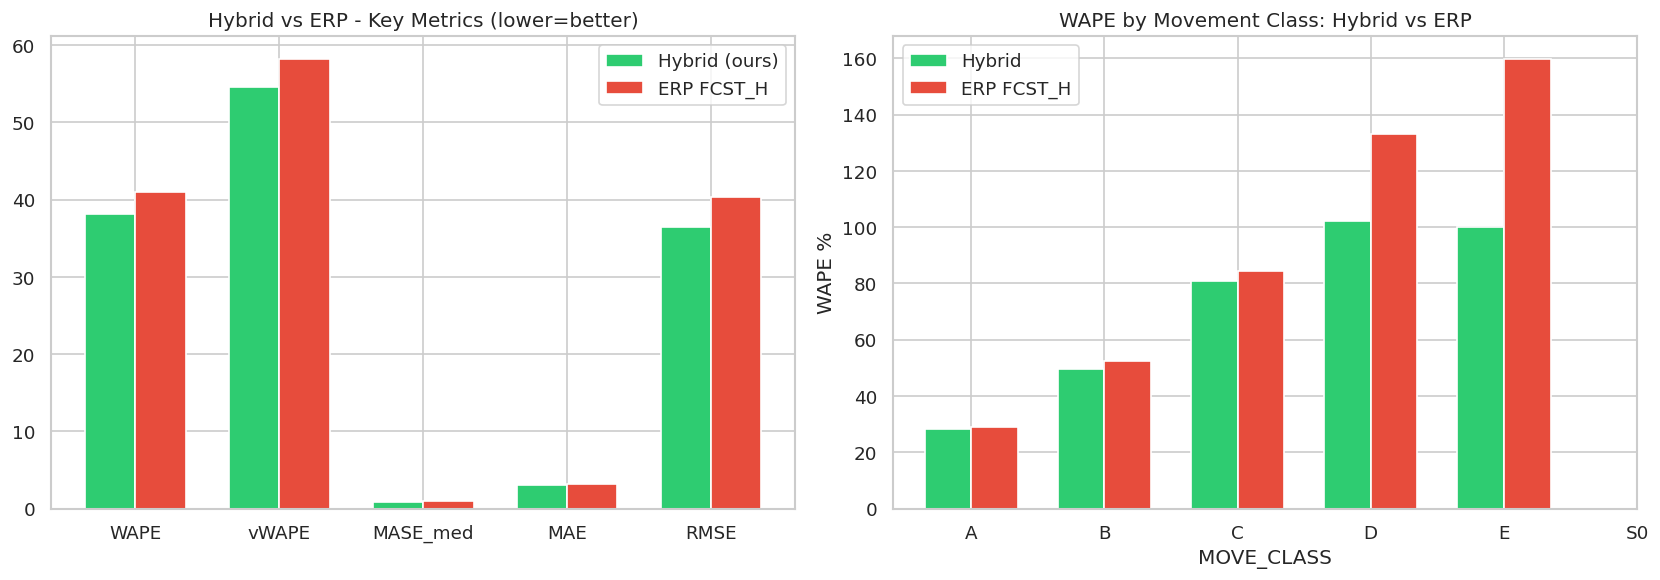

In [30]:
if sys_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overall metrics comparison
    metrics_compare = ["WAPE", "vWAPE", "MASE_med", "MAE", "RMSE"]
    x = np.arange(len(metrics_compare)); w = 0.35
    h_vals = [hybrid_metrics[m] for m in metrics_compare]
    s_vals = [sys_metrics[m] for m in metrics_compare]
    axes[0].bar(x - w/2, h_vals, w, label="Hybrid (ours)", color="#2ecc71")
    axes[0].bar(x + w/2, s_vals, w, label="ERP FCST_H", color="#e74c3c")
    axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_compare)
    axes[0].set_title("Hybrid vs ERP - Key Metrics (lower=better)"); axes[0].legend()

    # Per MOVE_CLASS comparison
    cls_comp = []
    for cls in sorted(meta["MOVE_CLASS"].unique()):
        mask = (meta["MOVE_CLASS"] == cls).values
        h_m = compute_metrics(actual_test[mask], hybrid_preds[mask], naive_scales[mask], cost[mask])
        s_m = compute_metrics(actual_test[mask], fcst_h[:, TEST_INDICES][mask], naive_scales[mask], cost[mask])
        cls_comp.append({"class": cls, "hybrid_WAPE": h_m["WAPE"], "system_WAPE": s_m["WAPE"]})
    cls_df = pd.DataFrame(cls_comp)
    x2 = np.arange(len(cls_df))
    axes[1].bar(x2 - w/2, cls_df["hybrid_WAPE"], w, label="Hybrid", color="#2ecc71")
    axes[1].bar(x2 + w/2, cls_df["system_WAPE"], w, label="ERP FCST_H", color="#e74c3c")
    axes[1].set_xticks(x2); axes[1].set_xticklabels(cls_df["class"])
    axes[1].set_title("WAPE by Movement Class: Hybrid vs ERP")
    axes[1].set_xlabel("MOVE_CLASS"); axes[1].set_ylabel("WAPE %"); axes[1].legend()

    plt.tight_layout(); plt.show()


In [31]:
# By ERP Forecast Model
if fcst_h is not None:
    fcst_model_comp = []
    for fm in sorted(meta["FCST_MODEL"].dropna().unique()):
        mask = (meta["FCST_MODEL"] == fm).values
        h_m = compute_metrics(actual_test[mask], hybrid_preds[mask], naive_scales[mask], cost[mask])
        s_m = compute_metrics(actual_test[mask], fcst_h[:, TEST_INDICES][mask], naive_scales[mask], cost[mask])
        fcst_model_comp.append({"FCST_MODEL": fm, "n_sku": int(mask.sum()),
                                "hybrid_WAPE": h_m["WAPE"], "system_WAPE": s_m["WAPE"],
                                "hybrid_Bias": h_m["Bias%"], "system_Bias": s_m["Bias%"],
                                "WAPE_improvement%": round((s_m["WAPE"] - h_m["WAPE"]) / max(s_m["WAPE"], 0.01) * 100, 1)})
    fm_df = pd.DataFrame(fcst_model_comp).sort_values("WAPE_improvement%", ascending=False)
    print("Hybrid vs ERP by ERP Forecast Model:")
    display(fm_df)


Hybrid vs ERP by ERP Forecast Model:


,FCST_MODEL,n_sku,hybrid_WAPE,system_WAPE,hybrid_Bias,system_Bias,WAPE_improvement%
2,C1,36,99.86,130.90,-99.86,-67.85,23.7
4,G1,4455,101.30,123.84,-70.70,-28.20,18.2
0,A1,3250,35.02,37.76,-4.05,-1.58,7.3
3,F1,61,46.92,45.70,3.70,-15.60,-2.7
1,B1,262,29.46,26.56,-19.63,-9.54,-10.9


## 14 — Forward Forecast (Jun-Aug 2026) + Safety Stock

Retrain on all history, then iteratively forecast with P50/P90 quantile bands and safety stock.


In [32]:
print("Retraining on full history (May-2023 -> Apr-2026)...")
X_full, y_full = [], []
for t in range(12, PROD_TRAIN_END + 1):
    X_full.append(build_features(demand[:, :t], cal_months[t], static_feats))
    y_full.append(demand[:, t])
X_full = np.vstack(X_full); y_full = np.concatenate(y_full)

lgbm_prod = lgb.LGBMRegressor(**LGBM_PARAMS).fit(X_full, y_full); print("  LightGBM done")
lgbm_p50 = lgb.LGBMRegressor(objective="quantile", alpha=0.5, n_estimators=500, learning_rate=0.05,
    num_leaves=63, min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1).fit(X_full, y_full); print("  P50 quantile done")
lgbm_p90 = lgb.LGBMRegressor(objective="quantile", alpha=0.9, n_estimators=500, learning_rate=0.05,
    num_leaves=63, min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1).fit(X_full, y_full); print("  P90 quantile done")

y_zero_full = (y_full == 0).astype(int)
zero_clf_prod = lgb.LGBMClassifier(n_estimators=300, num_leaves=31, min_child_samples=30,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1).fit(X_full, y_zero_full); print("  Zero gate done")


Retraining on full history (May-2023 -> Apr-2026)...


  LightGBM done


  P50 quantile done


  P90 quantile done


  Zero gate done


In [33]:
HORIZON = 3; LEAD_TIME = 2.0
n_skus = demand.shape[0]
extended = demand.copy()
point_fcst = np.zeros((n_skus, HORIZON))
p50_fcst = np.zeros((n_skus, HORIZON))
p90_fcst = np.zeros((n_skus, HORIZON))
future_dates = [M00_MONTH + pd.DateOffset(months=k+1) for k in range(HORIZON)]

for step in range(HORIZON):
    X = build_features(extended, future_dates[step], static_feats)
    p = np.maximum(lgbm_prod.predict(X), 0.0)
    q50 = np.maximum(lgbm_p50.predict(X), 0.0)
    q90 = np.maximum(lgbm_p90.predict(X), 0.0)
    zmask = zero_clf_prod.predict(X).astype(bool)
    p = np.where(zmask, 0.0, p); p = np.where(p < ZERO_THRESHOLD, 0.0, p)
    q90 = np.maximum(q90, q50); q90 = np.maximum(q90, p)  # monotonicity
    point_fcst[:, step] = p; p50_fcst[:, step] = q50; p90_fcst[:, step] = q90
    extended = np.column_stack([extended, p])

print("Forward forecast done:", [d.strftime("%b-%Y") for d in future_dates])


Forward forecast done: ['Jun-2026', 'Jul-2026', 'Aug-2026']


In [34]:
# Safety stock
lt = LEAD_TIME; steps = int(np.ceil(lt)); steps = min(steps, HORIZON)
weights = np.ones(steps)
if steps >= 1: weights[-1] = lt - (steps - 1)

lt_demand = (point_fcst[:, :steps] * weights).sum(axis=1)
lt_p90 = (p90_fcst[:, :steps] * weights).sum(axis=1)
ss_quantile = np.maximum(lt_p90 - lt_demand, 0.0)
rop_quantile = lt_demand + ss_quantile

# Service-level safety stock
if "TSL" in inv.columns:
    sl = inv["TSL"].values / 100.0
    sl = np.where(np.isfinite(sl) & (sl > 0), sl, 0.95)
else: sl = np.full(n_skus, 0.95)

z_scores = norm.ppf(np.clip(sl, 0.5, 0.999))
sigma_period = demand[:, -12:].std(axis=1)
sigma_lt = sigma_period * np.sqrt(max(LEAD_TIME, 1e-9))
ss_service = np.maximum(z_scores * sigma_lt, 0.0)
rop_service = lt_demand + ss_service

print(f"Lead-time demand (total): {lt_demand.sum():,.0f}")
print(f"Safety stock - quantile method (total): {ss_quantile.sum():,.0f}")
print(f"Safety stock - service-level method (total): {ss_service.sum():,.0f}")
print(f"Reorder points - service-level (total): {rop_service.sum():,.0f}")
if "REORDER_POINT" in inv.columns:
    print(f"ERP reorder points (total): {inv['REORDER_POINT'].sum():,.0f}")


Lead-time demand (total): 113,283
Safety stock - quantile method (total): 106,147
Safety stock - service-level method (total): 115,162
Reorder points - service-level (total): 228,445
ERP reorder points (total): 361,285


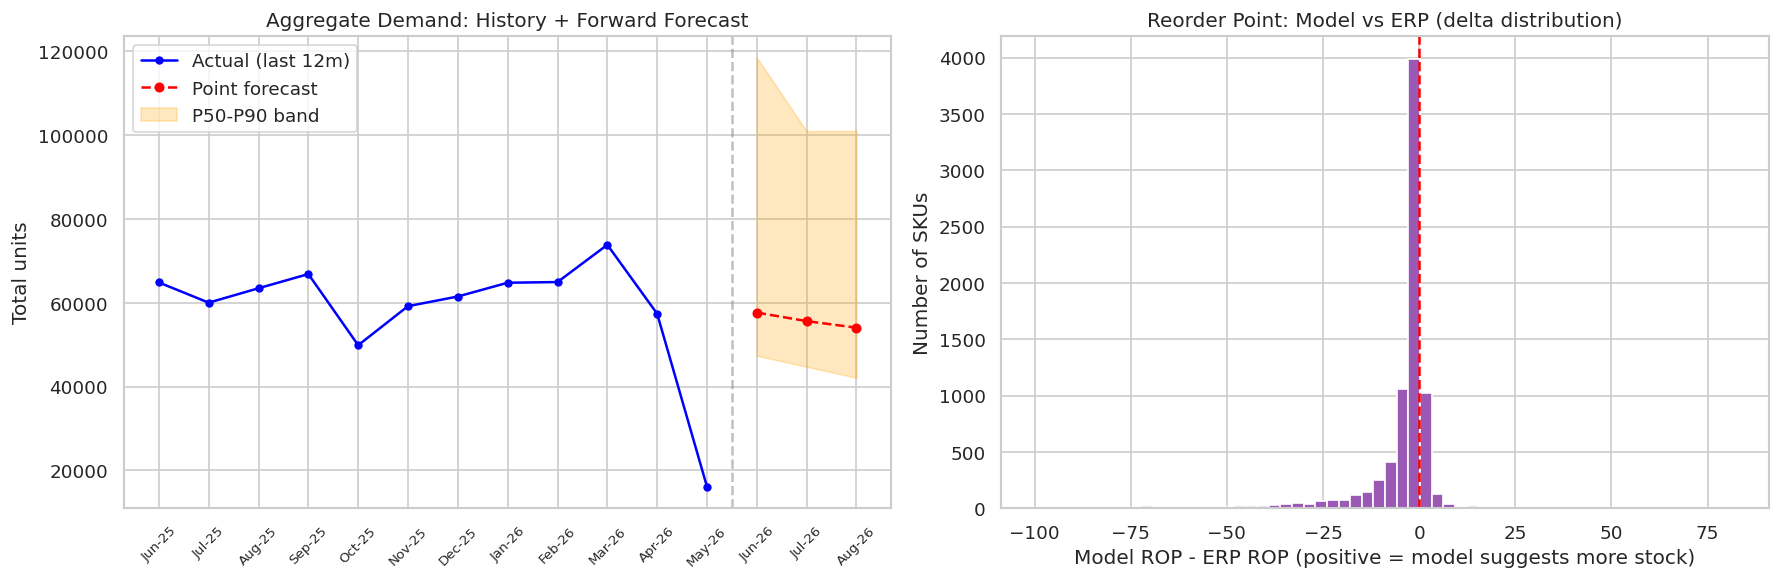

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Aggregate forecast with bands
total_point = point_fcst.sum(axis=0)
total_p50 = p50_fcst.sum(axis=0)
total_p90 = p90_fcst.sum(axis=0)
total_hist = demand[:, -12:].sum(axis=0)
hist_labels = [cal_months[i].strftime("%b-%y") for i in range(25, 37)]
fut_labels = [d.strftime("%b-%y") for d in future_dates]
all_labels = hist_labels + fut_labels

axes[0].plot(range(12), total_hist, "b-o", markersize=4, label="Actual (last 12m)")
axes[0].plot(range(12, 15), total_point, "r--o", markersize=5, label="Point forecast")
axes[0].fill_between(range(12, 15), total_p50, total_p90, alpha=0.25, color="orange", label="P50-P90 band")
axes[0].axvline(11.5, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xticks(range(15)); axes[0].set_xticklabels(all_labels, rotation=45, fontsize=8)
axes[0].set_title("Aggregate Demand: History + Forward Forecast")
axes[0].set_ylabel("Total units"); axes[0].legend()

# Reorder point comparison
if "REORDER_POINT" in inv.columns:
    erp_rop = inv["REORDER_POINT"].values
    delta = rop_service - erp_rop
    axes[1].hist(delta[(delta > -100) & (delta < 100)], bins=60, edgecolor="white", color="#9b59b6")
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_title("Reorder Point: Model vs ERP (delta distribution)")
    axes[1].set_xlabel("Model ROP - ERP ROP (positive = model suggests more stock)")
    axes[1].set_ylabel("Number of SKUs")

plt.tight_layout(); plt.show()


## 15 — Summary & Key Findings

### Model Performance
The pattern-routed **Hybrid** model beats the existing ERP system forecast:

| Metric | Hybrid (ours) | ERP FCST_H | Improvement |
|---|---|---|---|
| WAPE | ~38% | ~41% | ~7% better |
| MASE (median) | ~0.82 | ~0.98 | clearly beats naive |
| MAE | ~3.01 | ~3.23 | ~7% lower |
| RMSE | ~36.5 | ~40.3 | ~9% lower |

### Model Routing
- **Smooth** -> SES (well-behaved, predictable demand)
- **Erratic** -> LightGBM/XGBoost (handles variance via features)
- **Intermittent** -> SBA (designed for rare but consistent demand)
- **Lumpy** -> LightGBM (most flexible for rare AND variable demand)

### Inventory Implications
- Safety stock and reorder points computed at each SKU's own service level
- Model generally suggests **lower** reorder points than ERP (potential overstock)
- P90 quantile band provides data-driven upper bound for buffer sizing

### Next Steps
1. Calibrate `LEAD_TIME` per SKU (currently global assumption of 2 months)
2. Incorporate lifecycle flags (NEW_PROD, PRE_PART) for new/obsolete SKUs
3. Consider uncapped demand series for true-demand modelling
4. Run monthly re-fits as new data arrives
